# CNN-LSTM Preprocessing Pipeline: Spatiotemporal Alignment
This notebook handles the early-fusion data engineering required for the dual-branch CNN-LSTM architecture. It spatially filters OpenAQ sensors based on the boundaries of the Master GeoTIFF and engineers the cyclical and autoregressive temporal features required for the LSTM branch.

In [31]:
# Install required dependencies
# 'q' flag is for quiet mode to avoid flooding your notebook with installation logs
!pip install -q geopandas pandas numpy rasterio shapely rasterstats scikit-learn scipy torch scikit-optimize libpysal esda matplotlib

In [32]:
# Import required libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterio.windows import Window
from shapely.geometry import box
import os
import warnings
import glob
# Suppress minor warnings for cleaner output
warnings.filterwarnings('ignore')

## Configuration
Parameters needed early in the pipeline (patch/raster geometry, lag/gap settings) live here, since Python needs them defined before the functions that reference them as defaults are declared. Parameters specific to actually *running* a test (row caps, hyperparameters, search effort, evaluation folds, spatial-bias settings) live in their own "Testing Parameters" blocks placed immediately before each smoke-test cell further down, so you don't have to scroll back up here to tweak a test run.

In [33]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# --- Patch / raster geometry (Section 4.2.5) ---
PATCH_EXTENT_M = 320       # CNN's spatial footprint, in meters (320m x 320m)
RASTER_RESOLUTION_M = 10   # ground resolution the patch size above assumes

# --- Data preparation (Section 4.3, prepare_modeling_frame) ---
LAG_HOURS = (3, 2, 1)      # which past hours feed the LSTM (oldest first)
MAX_GAP_HOURS = 24         # longest gap that gets interpolated instead of dropped

# Testing-segment parameters (row caps, hyperparameters, search effort, evaluation folds,
# spatial-bias settings) are defined in their own "Testing Parameters" blocks right before each
# smoke-test cell further down in the notebook.

## Section 4.2.1 — General Data Preparation and Preprocessing
Shared preprocessing functions that build the spatial foundation (grid + morphology) consumed by both the XGBoost and CNN-LSTM branches.

### 4.2.1.1 Raw Data Ingestion, Sanitation, and CRS Alignment
Repairs invalid building geometries, hierarchically imputes missing street widths, and reprojects every vector layer from EPSG:4326 to the metric EPSG:32651 (UTM Zone 51N).

In [34]:
# ----------------------------------------------------------------------------
# 4.2.1.1 Raw Data Ingestion, Sanitation, and CRS Alignment
# ----------------------------------------------------------------------------

TARGET_CRS = "EPSG:32651"  # UTM Zone 51N (metric projection for the Philippines)

# Functional-class fallback widths (meters), used when both an explicit width and a lane
# count are unavailable for a street segment.
FUNCTIONAL_CLASS_WIDTHS = {
    "motorway": 20.0, "trunk": 16.0, "primary": 12.0, "secondary": 10.0,
    "tertiary": 8.0, "residential": 6.0, "unclassified": 5.0,
    "service": 4.0, "living_street": 4.0, "alley": 4.0, "track": 3.0,
}


def repair_geometries(gdf):
    """Fix self-intersections and open rings via a zero-distance buffer, mirroring the QGIS
    geometry-correction step applied to raw building footprints."""
    gdf = gdf.copy()
    invalid_mask = ~gdf.geometry.is_valid
    if invalid_mask.any():
        gdf.loc[invalid_mask, "geometry"] = gdf.loc[invalid_mask, "geometry"].buffer(0)
    return gdf


def impute_street_widths(streets_gdf, width_col="width", lanes_col="lanes", highway_col="highway",
                          lane_width_m=3.0, min_width=1.5, max_width=70.0,
                          functional_class_widths=None):
    """Hierarchical street-width imputation: explicit recorded width takes priority; if missing,
    lane count x `lane_width_m`; if both are absent, a functional-class fallback threshold is used.
    Result is clipped to [min_width, max_width] to filter anomalies while preserving legitimate layouts."""
    functional_class_widths = functional_class_widths or FUNCTIONAL_CLASS_WIDTHS
    gdf = streets_gdf.copy()

    explicit_width = pd.to_numeric(gdf[width_col], errors="coerce") if width_col in gdf else pd.Series(np.nan, index=gdf.index)
    lanes = pd.to_numeric(gdf[lanes_col], errors="coerce") if lanes_col in gdf else pd.Series(np.nan, index=gdf.index)

    calculated = explicit_width.fillna(lanes * lane_width_m)

    if highway_col in gdf.columns:
        # OSM sometimes stores multiple highway tags per way as a list; use the first as the primary class
        primary_class = gdf[highway_col].apply(lambda v: v[0] if isinstance(v, list) else v)
        calculated = calculated.fillna(primary_class.map(functional_class_widths))

    calculated = calculated.fillna(functional_class_widths["unclassified"])
    gdf["calculated_width"] = calculated.clip(lower=min_width, upper=max_width)
    return gdf


def reproject_layer(gdf, target_crs=TARGET_CRS):
    """Reproject a vector layer from EPSG:4326 (or any source CRS) to the metric target CRS; no-op if
    already aligned."""
    if gdf.crs is None:
        raise ValueError("Input GeoDataFrame has no CRS defined; cannot safely reproject.")
    return gdf.to_crs(target_crs) if str(gdf.crs) != str(target_crs) else gdf


def ingest_and_sanitize_vectors(buildings_path, streets_path, target_crs=TARGET_CRS, **impute_kwargs):
    """Ingest building footprints and road centerlines, repair geometries, impute street widths, and
    align both layers to the metric CRS."""
    buildings_gdf = repair_geometries(gpd.read_file(buildings_path))
    streets_gdf = impute_street_widths(gpd.read_file(streets_path), **impute_kwargs)

    buildings_gdf = reproject_layer(buildings_gdf, target_crs)
    streets_gdf = reproject_layer(streets_gdf, target_crs)
    return buildings_gdf, streets_gdf

### 4.2.1.2 Base Vector Grid Generation and Morphological Metric Extraction
Generates a uniform fishnet grid over the buffered sensor bounding box and extracts zonal building-height/NDVI statistics, building density, and canyon aspect ratio per cell.

In [35]:
# ----------------------------------------------------------------------------
# 4.2.1.2 Base Vector Grid Generation and Morphological Metric Extraction
# ----------------------------------------------------------------------------

def generate_vector_grid(sensors_gdf, cell_size_m=500, buffer_m=2000, crs=TARGET_CRS):
    """Build a uniform fishnet grid over the sensor bounding box, padded by `buffer_m` so edge sensors
    capture the morphology of their immediate perimeter neighborhoods."""
    sensors_gdf = reproject_layer(sensors_gdf, crs)
    minx, miny, maxx, maxy = sensors_gdf.total_bounds
    minx, miny, maxx, maxy = minx - buffer_m, miny - buffer_m, maxx + buffer_m, maxy + buffer_m

    cells = []
    row_index = 0
    y = miny
    while y < maxy:
        col_index = 0
        x = minx
        while x < maxx:
            cells.append({
                "geometry": box(x, y, x + cell_size_m, y + cell_size_m),
                "row_index": row_index,
                "col_index": col_index,
            })
            x += cell_size_m
            col_index += 1
        y += cell_size_m
        row_index += 1

    grid_gdf = gpd.GeoDataFrame(cells, crs=crs)
    grid_gdf.insert(0, "grid_id", range(1, len(grid_gdf) + 1))
    return grid_gdf


def compute_raster_zonal_stats(grid_gdf, raster_path, stats=("mean", "std"), prefix="bh"):
    """Zonal statistics (e.g. mean/std building height, mean NDVI) per grid cell from a raster layer."""
    from rasterstats import zonal_stats

    results = zonal_stats(grid_gdf, raster_path, stats=list(stats), all_touched=True)
    grid_gdf = grid_gdf.copy()
    for stat in stats:
        grid_gdf[f"{prefix}_{stat}"] = [r[stat] for r in results]
    return grid_gdf


def compute_building_density(grid_gdf, buildings_gdf):
    """Fraction of each grid cell's area covered by building footprints."""
    buildings_gdf = reproject_layer(buildings_gdf, grid_gdf.crs)
    cell_area = grid_gdf.set_index("grid_id").geometry.area

    intersections = gpd.overlay(grid_gdf[["grid_id", "geometry"]], buildings_gdf[["geometry"]], how="intersection")
    covered_area = intersections.geometry.area.groupby(intersections["grid_id"]).sum()

    grid_gdf = grid_gdf.copy()
    grid_gdf["bldg_dens"] = (grid_gdf["grid_id"].map(covered_area).fillna(0) / grid_gdf["grid_id"].map(cell_area)).values
    return grid_gdf


def compute_canyon_aspect_ratio(grid_gdf, streets_gdf, height_raster_path, width_col="calculated_width"):
    """Buffer street segments by their calculated width, extract local building heights within the buffer,
    and derive the canyon aspect ratio (height / width) per grid cell."""
    from rasterstats import zonal_stats

    streets_gdf = reproject_layer(streets_gdf, grid_gdf.crs)
    street_buffers = streets_gdf.copy()
    street_buffers["geometry"] = street_buffers.buffer(street_buffers[width_col] / 2.0)

    joined = gpd.sjoin(street_buffers, grid_gdf[["grid_id", "geometry"]], predicate="intersects", how="inner")

    aspect_ratios = {}
    for grid_id, group in joined.groupby("grid_id"):
        merged_buffer = group.geometry.unary_union
        buffer_gdf = gpd.GeoDataFrame({"geometry": [merged_buffer]}, crs=grid_gdf.crs)
        mean_height = zonal_stats(buffer_gdf, height_raster_path, stats=["mean"])[0]["mean"] or 0.0
        mean_width = group[width_col].mean()
        aspect_ratios[grid_id] = mean_height / mean_width if mean_width else np.nan

    grid_gdf = grid_gdf.copy()
    grid_gdf["aspect_ratio_mean"] = grid_gdf["grid_id"].map(aspect_ratios)
    return grid_gdf


def extract_morphological_metrics(grid_gdf, height_raster_path, ndvi_raster_path, buildings_gdf, streets_gdf):
    """Run the full grid -> morphology pipeline: building height stats, NDVI, building density, and
    canyon aspect ratio, transforming raw physical geometries into a numeric tabular profile per grid cell."""
    grid_gdf = compute_raster_zonal_stats(grid_gdf, height_raster_path, stats=("mean", "std"), prefix="bh")
    grid_gdf = compute_raster_zonal_stats(grid_gdf, ndvi_raster_path, stats=("mean",), prefix="ndvi")
    grid_gdf = compute_building_density(grid_gdf, buildings_gdf)
    grid_gdf = compute_canyon_aspect_ratio(grid_gdf, streets_gdf, height_raster_path)
    return grid_gdf

### 4.2.1.3 Spatiotemporal Alignment and Temporal Feature Engineering
Joins sensors to grid cells, broadcasts static morphology to every recorded hour, and engineers cyclical hour encodings, autoregressive lags, capped linear interpolation, and leakage-safe train-only scaling.

In [36]:
# ----------------------------------------------------------------------------
# 4.2.1.3 Spatiotemporal Alignment and Temporal Feature Engineering
# ----------------------------------------------------------------------------

def spatial_join_sensors_to_grid(sensors_gdf, grid_gdf):
    """Map each sensor location to its containing grid cell."""
    sensors_gdf = reproject_layer(sensors_gdf, grid_gdf.crs)
    joined = gpd.sjoin(sensors_gdf, grid_gdf[["grid_id", "geometry"]], predicate="within", how="left")
    return joined.drop(columns="index_right")


def merge_pm25_with_morphology(pm25_df, sensor_to_grid_df, grid_morphology_df, sensor_id_col="location_id"):
    """Broadcast static morphological metrics to every timestamp recorded at that sensor's grid cell,
    keyed on grid_id, without duplicating or losing rows."""
    id_to_grid = sensor_to_grid_df.set_index(sensor_id_col)["grid_id"]
    pm25_df = pm25_df.copy()
    pm25_df["grid_id"] = pm25_df[sensor_id_col].map(id_to_grid)

    morphology_cols = [c for c in grid_morphology_df.columns if c != "geometry"]
    return pm25_df.merge(grid_morphology_df[morphology_cols], on="grid_id", how="left")


def engineer_cyclical_time_features(df, timestamp_col="local_timestamp"):
    """Sine/cosine encode the hour of day so 23:00 and 00:00 are numerically adjacent."""
    df = df.copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])
    hour = df[timestamp_col].dt.hour
    df["sin_hour"] = np.sin(2 * np.pi * hour / 24)
    df["cos_hour"] = np.cos(2 * np.pi * hour / 24)
    return df


def engineer_lag_features(df, target_col="pm25_value", group_col="location_id",
                           timestamp_col="local_timestamp", lags=(1, 2, 3), rolling_window=None):
    """Chronologically group by sensor and create sliding-window lags (t-1, t-2, ...), plus an optional
    rolling mean/std, to capture pollutant autoregression."""
    df = df.sort_values([group_col, timestamp_col]).copy()
    grouped_target = df.groupby(group_col)[target_col]

    for lag in lags:
        df[f"{target_col}_t-{lag}"] = grouped_target.shift(lag)

    if rolling_window:
        df[f"{target_col}_roll_mean_{rolling_window}"] = grouped_target.transform(
            lambda s: s.shift(1).rolling(rolling_window).mean())
        df[f"{target_col}_roll_std_{rolling_window}"] = grouped_target.transform(
            lambda s: s.shift(1).rolling(rolling_window).std())
    return df


def interpolate_missing_readings(df, value_col="pm25_value", group_col="location_id",
                                  timestamp_col="local_timestamp", max_gap_hours=24):
    """Linearly interpolate missing readings per sensor, capped at `max_gap_hours` so extended sensor
    downtime is never fabricated."""
    df = df.sort_values([group_col, timestamp_col]).copy()
    df[value_col] = df.groupby(group_col)[value_col].transform(
        lambda s: s.interpolate(method="linear", limit=max_gap_hours, limit_direction="both"))
    return df


def fit_scaler_on_train_only(df, feature_cols, train_index):
    """Fit a StandardScaler exclusively on training-index rows to prevent leakage into the validation
    distribution, then transform the full frame."""
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler().fit(df.loc[train_index, feature_cols])
    scaled_df = df.copy()
    scaled_df[feature_cols] = scaler.transform(df[feature_cols])
    return scaled_df, scaler


def apply_scaler(df, feature_cols, scaler):
    """Apply an already-fitted scaler (fit on training data) to a validation/test frame."""
    df = df.copy()
    df[feature_cols] = scaler.transform(df[feature_cols])
    return df

## Section 4.2.3 — Raster-Vector Integration Pipeline
### Resolution Harmonization and Reprojection
Aligns the 4m building-height raster and 10m NDVI raster to a common 10m x 10m footprint via reprojection, bilinear resampling, and boundary clipping/masking.

In [37]:
# ----------------------------------------------------------------------------
# 4.2.3 Raster-Vector Integration Pipeline
# Resolution Harmonization and Reprojection
# ----------------------------------------------------------------------------

def reproject_raster(src_path, dst_path, dst_crs=TARGET_CRS, resampling="bilinear"):
    """Reproject a raster (e.g. WGS 84 height/NDVI tiles) into the metric target CRS."""
    from rasterio.warp import calculate_default_transform, reproject, Resampling

    resampling_method = getattr(Resampling, resampling)
    with rasterio.open(src_path) as src:
        transform, width, height = calculate_default_transform(src.crs, dst_crs, src.width, src.height, *src.bounds)
        profile = src.profile.copy()
        profile.update(crs=dst_crs, transform=transform, width=width, height=height)

        with rasterio.open(dst_path, "w", **profile) as dst:
            for band in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, band), destination=rasterio.band(dst, band),
                    src_transform=src.transform, src_crs=src.crs,
                    dst_transform=transform, dst_crs=dst_crs, resampling=resampling_method,
                )
    return dst_path


def resample_raster_to_resolution(src_path, dst_path, target_resolution_m=10.0, resampling="bilinear"):
    """Resample a raster (e.g. the 4m building-height layer) to a target ground resolution, matching the
    10m NDVI grid. Bilinear interpolation is used (rather than nearest-neighbor) to preserve continuous
    height transitions across urban canyons."""
    from rasterio.enums import Resampling as ResamplingEnum

    resampling_method = getattr(ResamplingEnum, resampling)
    with rasterio.open(src_path) as src:
        new_width = max(1, round(src.width * src.res[0] / target_resolution_m))
        new_height = max(1, round(src.height * src.res[1] / target_resolution_m))

        data = src.read(out_shape=(src.count, new_height, new_width), resampling=resampling_method)
        new_transform = src.transform * src.transform.scale(src.width / new_width, src.height / new_height)

        profile = src.profile.copy()
        profile.update(transform=new_transform, width=new_width, height=new_height)

        with rasterio.open(dst_path, "w", **profile) as dst:
            dst.write(data)
    return dst_path


def clip_and_mask_to_boundary(src_path, boundary_gdf, dst_path):
    """Clip a raster to the study-area boundary and mask it to a shared NoData extent."""
    from rasterio.mask import mask as rio_mask

    with rasterio.open(src_path) as src:
        boundary = boundary_gdf.to_crs(src.crs)
        out_image, out_transform = rio_mask(src, boundary.geometry, crop=True)
        profile = src.profile.copy()
        profile.update(height=out_image.shape[1], width=out_image.shape[2], transform=out_transform)

        with rasterio.open(dst_path, "w", **profile) as dst:
            dst.write(out_image)
    return dst_path

### Vector-to-Raster Conversion for CNN-LSTM
Burns building density and street-derived aspect ratio into raster form and stacks them with the height and NDVI rasters into the multi-band Master GeoTIFF.

In [38]:
# ----------------------------------------------------------------------------
# Vector-to-Raster Conversion for CNN-LSTM
# ----------------------------------------------------------------------------

def rasterize_building_density(buildings_gdf, reference_profile):
    """Rasterize building footprints onto the common 10m grid; each pixel = fraction of cell area covered by footprints."""
    from rasterio.features import rasterize

    out_shape = (reference_profile["height"], reference_profile["width"])
    shapes = ((geom, 1) for geom in buildings_gdf.geometry)
    return rasterize(shapes, out_shape=out_shape, transform=reference_profile["transform"],
                      fill=0, all_touched=True, dtype="float32")


def rasterize_street_width(streets_gdf, reference_profile, width_col="calculated_width"):
    """Rasterize buffered road centerlines onto the common grid; each pixel stores the maximum width
    of any intersecting segment."""
    from rasterio.features import rasterize
    from rasterio.enums import MergeAlg

    out_shape = (reference_profile["height"], reference_profile["width"])
    shapes = ((geom, width) for geom, width in zip(streets_gdf.geometry, streets_gdf[width_col]) if pd.notna(width))
    return rasterize(shapes, out_shape=out_shape, transform=reference_profile["transform"],
                      fill=0.0, all_touched=True, dtype="float32", merge_alg=MergeAlg.replace)


def compute_pixel_aspect_ratio(height_raster, street_width_raster, neighborhood_m=50, resolution_m=10):
    """Per-pixel canyon aspect ratio: mean building height within a perpendicular neighborhood of each
    buffered road pixel, divided by the street width at that pixel."""
    from scipy.ndimage import uniform_filter

    neighborhood_px = max(1, round(neighborhood_m / resolution_m))
    local_mean_height = uniform_filter(height_raster.astype("float32"), size=neighborhood_px * 2 + 1)

    with np.errstate(divide="ignore", invalid="ignore"):
        aspect_ratio = np.where(street_width_raster > 0, local_mean_height / street_width_raster, 0.0)
    return aspect_ratio.astype("float32")


def build_master_geotiff(band_arrays, reference_profile, output_path, band_names=None):
    """Stack aligned single-band arrays (height, NDVI, building density, aspect ratio, ...) into the
    multi-band Master GeoTIFF consumed by the CNN branch."""
    profile = reference_profile.copy()
    profile.update(count=len(band_arrays), dtype="float32")

    with rasterio.open(output_path, "w", **profile) as dst:
        for i, arr in enumerate(band_arrays, start=1):
            dst.write(arr.astype("float32"), i)
        if band_names:
            dst.descriptions = tuple(band_names)
    return output_path

### Cross-Architecture Alignment
Both pipelines derive from the same reprojected, identically clipped source layers — the vector grid anchors XGBoost's zonal statistics while also defining the coordinate system used for CNN-LSTM patch extraction. `validate_grid_alignment` sanity-checks that the two representations agree.

In [39]:
# ----------------------------------------------------------------------------
# Cross-Architecture Alignment
# ----------------------------------------------------------------------------

def validate_grid_alignment(grid_gdf, master_raster_path):
    """Sanity-check that the vector grid (XGBoost's spatial index) and the Master GeoTIFF
    (CNN-LSTM's coordinate system) share a consistent CRS and overlapping extent."""
    with rasterio.open(master_raster_path) as src:
        raster_crs = src.crs
        raster_bounds = box(*src.bounds)

    grid_bounds = box(*grid_gdf.total_bounds)
    return {
        "crs_match": str(grid_gdf.crs) == str(raster_crs),
        "extent_overlap_fraction": grid_bounds.intersection(raster_bounds).area / grid_bounds.area,
    }

## Section 4.2.5 — CNN-LSTM-Exclusive Preprocessing (Dual-Branch Tensor Pipeline)
### Spatial Patch Extent and Dual-Branch Dataset Generation
Resamples the time series to strict hourly intervals, standard-scales the target, and defines the `CNNLSTMDataset` class that yields a 320m x 320m spatial patch (CNN branch) alongside the matching lag-feature sequence (LSTM branch) per sample — discarding any window broken by an un-interpolated offline gap.

In [40]:
# ----------------------------------------------------------------------------
# 4.2.5 CNN-LSTM-Exclusive Preprocessing (Dual-Branch Tensor Pipeline)
# Spatial Patch Extent and Dual-Branch Dataset Generation
# ----------------------------------------------------------------------------
# PATCH_EXTENT_M and RASTER_RESOLUTION_M are defined in the Configuration cell above.


def resample_time_series_hourly(df, timestamp_col="local_timestamp", group_col="location_id", value_cols=None):
    """Resample each sensor's series onto a strict hourly index before tensor extraction."""
    if value_cols is None:
        value_cols = [c for c in df.columns if c not in (timestamp_col, group_col)]

    df = df.copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])

    resampled = []
    for gid, group in df.groupby(group_col):
        hourly = group.set_index(timestamp_col).sort_index()[value_cols].resample("1h").mean()
        hourly[group_col] = gid
        resampled.append(hourly.reset_index())
    return pd.concat(resampled, ignore_index=True)


def scale_target_standard(df, target_col="pm25_value", train_index=None):
    """Standard-scale the PM2.5 target to stabilize LSTM gradient convergence; fit strictly on training rows when provided."""
    from sklearn.preprocessing import StandardScaler

    fit_index = train_index if train_index is not None else df.index
    scaler = StandardScaler().fit(df.loc[fit_index, [target_col]])

    df = df.copy()
    df[f"{target_col}_scaled"] = scaler.transform(df[[target_col]])
    return df, scaler


def validate_temporal_contiguity(df, group_col="location_id", timestamp_col="local_timestamp", sequence_length=3):
    """Flag rows whose preceding `sequence_length` hourly steps are all present with no un-interpolated gap,
    so sliding windows broken by extended sensor downtime can be dynamically discarded."""
    df = df.sort_values([group_col, timestamp_col]).copy()
    timestamps = pd.to_datetime(df[timestamp_col])

    window_start = df.groupby(group_col)[timestamp_col].transform(lambda s: pd.to_datetime(s).shift(sequence_length))
    expected_delta = pd.Timedelta(hours=1) * sequence_length

    df["_contiguous_window"] = (timestamps - window_start) == expected_delta
    return df


def extract_spatial_patch(raster_dataset, x, y, patch_extent_m=PATCH_EXTENT_M, resolution_m=RASTER_RESOLUTION_M):
    """Crop a zero-padded (bands, H, W) patch of `patch_extent_m` x `patch_extent_m` centered on a
    projected (x, y) coordinate from an already-open rasterio dataset (zero-padded at raster edges)."""
    patch_px = int(round(patch_extent_m / resolution_m))
    row, col = raster_dataset.index(x, y)
    half = patch_px // 2

    row_start, col_start = row - half, col - half
    row_end, col_end = row_start + patch_px, col_start + patch_px

    read_row_start, read_row_end = max(row_start, 0), min(row_end, raster_dataset.height)
    read_col_start, read_col_end = max(col_start, 0), min(col_end, raster_dataset.width)

    window = Window(read_col_start, read_row_start, read_col_end - read_col_start, read_row_end - read_row_start)
    data = raster_dataset.read(window=window)

    patch = np.zeros((raster_dataset.count, patch_px, patch_px), dtype=np.float32)
    patch[:,
          read_row_start - row_start: read_row_start - row_start + data.shape[1],
          read_col_start - col_start: read_col_start - col_start + data.shape[2]] = data
    return patch

In [41]:
# ----------------------------------------------------------------------------
# Dual-Branch PyTorch Dataset
# ----------------------------------------------------------------------------

import torch
from torch.utils.data import Dataset


class CNNLSTMDataset(Dataset):
    """Yields (spatial_tensor, temporal_tensor, target) samples for the dual-branch CNN-LSTM model.

    spatial_tensor: zero-padded (bands, H, W) crop of the Master GeoTIFF, `patch_extent_m` wide,
        centered on the sensor's projected coordinates (CNN branch).
    temporal_tensor: (seq_len, 1) historical PM2.5 lag sequence, oldest first — `lag_cols` must
        already be ordered oldest-to-newest (e.g. t-3, t-2, t-1) — ready to feed an LSTM directly (LSTM branch).
    target: the PM2.5 reading at the current timestep.

    Rows whose lag window is interrupted by an un-interpolated offline gap are dropped at
    construction time via `validate_temporal_contiguity`.
    """

    def __init__(self, samples_df, master_raster_path, lag_cols, target_col="pm25_target",
                 x_col="x_coordinate", y_col="y_coordinate", timestamp_col="local_timestamp",
                 group_col="location_id", sequence_length=3,
                 patch_extent_m=PATCH_EXTENT_M, resolution_m=RASTER_RESOLUTION_M):
        self.master_raster_path = master_raster_path
        self.lag_cols = list(lag_cols)
        self.target_col = target_col
        self.x_col = x_col
        self.y_col = y_col
        self.patch_extent_m = patch_extent_m
        self.resolution_m = resolution_m
        self._raster = None

        checked = validate_temporal_contiguity(samples_df, group_col, timestamp_col, sequence_length)
        self.samples = checked.loc[checked["_contiguous_window"]].reset_index(drop=True)

    def _raster_dataset(self):
        # Lazily open the raster so the Dataset stays picklable across DataLoader worker processes
        if self._raster is None:
            self._raster = rasterio.open(self.master_raster_path)
        return self._raster

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row = self.samples.iloc[idx]

        spatial_patch = extract_spatial_patch(
            self._raster_dataset(), row[self.x_col], row[self.y_col],
            patch_extent_m=self.patch_extent_m, resolution_m=self.resolution_m,
        )
        # Reshape to (seq_len, input_size=1) so it can be fed straight into a batch_first LSTM
        temporal_sequence = row[self.lag_cols].to_numpy(dtype=np.float32).reshape(-1, 1)
        target = np.float32(row[self.target_col])

        return (
            torch.from_numpy(spatial_patch).float(),
            torch.from_numpy(temporal_sequence).float(),
            torch.tensor(target).float(),
        )

    def __del__(self):
        if self._raster is not None:
            self._raster.close()

---
## Pilot Execution
The cells below run an already-built pilot version of this pipeline (a precomputed `master_morphology_stack_500m.tif` and `full_morphology_grid.csv`) through the spatiotemporal alignment functions above, to sanity-check the sensor-to-grid join before scaling to the full 10m-resolution / 2,000m-buffer implementation.

## Step 1: Spatial Boundary Filtering
Instead of manually mapping coordinates, we extract the exact bounding box from the `master_10m_morphology.tif`. We then perform a spatial intersection with the `openaq_sensors.gpkg` to automatically drop any sensors located outside the study area (Manila and Quezon City).

In [42]:
# Define file paths
master_tif_path = "master_morphology_stack_500m.tif"
sensors_gpkg_path = "D:\\Thesis Transformed Data\\OpenAQ_Sensors.gpkg"

# 1. Load the OpenAQ sensors GeoPackage
sensors_gdf = gpd.read_file(sensors_gpkg_path)

# 2. Extract the bounding box and CRS from the Master TIF
with rasterio.open(master_tif_path) as src:
    bounds = src.bounds
    tif_crs = src.crs
    grid_polygon = box(bounds.left, bounds.bottom, bounds.right, bounds.top)

# 3. Create a GeoDataFrame for the raster boundary
grid_gdf = gpd.GeoDataFrame({'geometry': [grid_polygon]}, crs=tif_crs)

# 4. Standardize Coordinate Reference Systems (CRS)
# Ensure the sensors match the metric UTM Zone 51N projection of the TIF
if sensors_gdf.crs != grid_gdf.crs:
    print(f"Reprojecting sensors from {sensors_gdf.crs} to {grid_gdf.crs}...")
    sensors_gdf = sensors_gdf.to_crs(grid_gdf.crs)

# 5. Spatial Intersection
# This isolates only the sensors that physically fall inside the TIF boundaries
valid_sensors_gdf = gpd.overlay(sensors_gdf, grid_gdf, how='intersection')

# Extract the valid IDs for the next step
valid_sensors_list = valid_sensors_gdf['location_id'].tolist()
print(f"Spatial filtering complete. Found {len(valid_sensors_list)} valid sensors inside the study area.")

Reprojecting sensors from EPSG:4326 to PROJCS["WGS 84 / UTM zone 51N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32651"]]...
Spatial filtering complete. Found 18 valid sensors inside the study area.


## Step 2: Temporal Feature Engineering & Merging
For every valid sensor identified in Step 1, we load its corresponding time-series `.csv`. We extract the projected $X$ and $Y$ coordinates, engineer the sliding window lags ($PM_{2.5}$ at $t-1, t-2, t-3$), and apply cyclical encoding to the timestamps. We concatenate all processed sensor DataFrames into a single, flattened master table and export it. This `.csv` acts as the definitive index for the PyTorch `Dataset` class to load temporal features and fetch the corresponding spatial crops on the fly.

In [43]:
import glob
master_training_data = []

# Directory where your individual sensor CSVs are stored
csv_directory = r"D:\Thesis Transformed Data\Pilot testing"

# ==========================================
# NEW: Load the CSV containing Latitude and Longitude
# ==========================================
locations_csv_path = "OpenAQ Sensor Locations - OpenAQ Sensor Locations.csv" # Change to your actual file name
locations_df = pd.read_csv(locations_csv_path)

print("Commencing temporal feature engineering...")

for sensor_id in valid_sensors_list:
    # FIX: search recursively under csv_directory instead of assuming a hard-coded
    # subfolder name (e.g. "Air Data" vs "AirData"). This finds the file regardless
    # of which subfolder it actually lives in, or if it's directly in csv_directory.
    search_pattern = os.path.join(csv_directory, "**", f"openaq_{sensor_id}*.csv")
    matching_files = glob.glob(search_pattern, recursive=True)

    try:
        # FIX: glob.glob() returns a LIST of paths, but pd.read_csv() needs a single
        # path string. Passing the list directly (the old code) was the root cause
        # of every sensor being skipped with a misleading "not found" message.
        if not matching_files:
            print(f" Warning: No CSV found for sensor {sensor_id}. Searched pattern: {search_pattern}")
            continue
        if len(matching_files) > 1:
            print(f" Note: Multiple files matched sensor {sensor_id}, using the first: {matching_files[0]}")

        # Load the temporal data
        df = pd.read_csv(matching_files[0])

        # Chronological sorting
        df['local_timestamp'] = pd.to_datetime(df['local_timestamp'])
        df = df.sort_values(by='local_timestamp').reset_index(drop=True)

        # 1. Assign Projected Spatial Coordinates (Metric X/Y)
        # Pull the exact metric coordinates directly from the GeoDataFrame geometry
        sensor_row = valid_sensors_gdf[valid_sensors_gdf['location_id'] == sensor_id].iloc[0]
        df['x_coordinate'] = sensor_row.geometry.x
        df['y_coordinate'] = sensor_row.geometry.y

        # ==========================================
        # NEW: Assign Raw GPS Coordinates (Lat/Lon)
        # ==========================================
        # Find this specific sensor's row in the locations CSV and extract lat/lon
        sensor_lat = locations_df.loc[locations_df['location_id'] == sensor_id, 'latitude'].values[0]
        sensor_lon = locations_df.loc[locations_df['location_id'] == sensor_id, 'longitude'].values[0]

        df['latitude'] = sensor_lat
        df['longitude'] = sensor_lon

        # 2. Cyclical Temporal Encoding
        df['hour'] = df['local_timestamp'].dt.hour
        df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)

        # 3. Autoregressive Lags (Sliding Window)
        df['pm25_t-1'] = df['pm25_value'].shift(1)
        df['pm25_t-2'] = df['pm25_value'].shift(2)
        df['pm25_t-3'] = df['pm25_value'].shift(3)

        # 4. Target Variable Definition
        df['pm25_target'] = df['pm25_value']

        # Drop the initial rows that contain NaN values due to the shift() function
        df = df.dropna().reset_index(drop=True)

        # Append to master list
        master_training_data.append(df)
        print(f" Successfully processed sensor {sensor_id} | Rows: {len(df)}")

    except IndexError:
        print(f" Warning: Sensor {sensor_id} missing from locations CSV. Skipping.")
    except Exception as e:
        print(f" Error processing sensor {sensor_id}: {e}")

if master_training_data:
    # Concatenate all valid sensor data
    final_df = pd.concat(master_training_data, ignore_index=True)

    # Isolate only the features required by the CNN-LSTM
    columns_to_keep = [
        'local_timestamp',
        'location_id',
        'latitude',      # <--- Added
        'longitude',     # <--- Added
        'x_coordinate',
        'y_coordinate',
        'sin_hour',
        'cos_hour',
        'pm25_t-1',
        'pm25_t-2',
        'pm25_t-3',
        'pm25_target'
    ]
    final_df = final_df[columns_to_keep]

    # Export the finalized dataset
    output_filename = "Master_DL_Ready.csv"
    final_df.to_csv(output_filename, index=False)

    print("==================================================")
    print(f"Master dataset successfully compiled and saved as '{output_filename}'.")
    print(f"Total Training Samples: {len(final_df)}")
    print("==================================================")
    display(final_df.head())
else:
    print("No valid training data was generated. Please check your file paths and CRS.")


Commencing temporal feature engineering...
 Successfully processed sensor 4797640 | Rows: 6379
 Successfully processed sensor 3370151 | Rows: 10275
 Successfully processed sensor 4797661 | Rows: 6392
 Successfully processed sensor 4963739 | Rows: 7113
 Successfully processed sensor 4797651 | Rows: 6368
 Successfully processed sensor 4797637 | Rows: 6406
 Successfully processed sensor 6303934 | Rows: 1244
 Successfully processed sensor 4797641 | Rows: 6380
 Successfully processed sensor 4797643 | Rows: 6406
 Successfully processed sensor 4797642 | Rows: 6393
 Successfully processed sensor 4797638 | Rows: 6441
 Successfully processed sensor 3015285 | Rows: 12503
 Successfully processed sensor 3990425 | Rows: 8605
 Successfully processed sensor 4797645 | Rows: 6412
 Successfully processed sensor 4797646 | Rows: 6384
 Successfully processed sensor 4797649 | Rows: 6413
 Successfully processed sensor 4797650 | Rows: 6349
 Successfully processed sensor 4797655 | Rows: 6378
Master dataset succ

,local_timestamp,location_id,latitude,longitude,x_coordinate,y_coordinate,sin_hour,cos_hour,pm25_t-1,pm25_t-2,pm25_t-3,pm25_target
0,2025-06-20 06:00:00+08:00,4797640,14.5688,121.01795,286456.363875,1.611564e+06,1.000000,6.123234e-17,23.3,16.8,17.3,55.1
1,2025-06-20 07:00:00+08:00,4797640,14.5688,121.01795,286456.363875,1.611564e+06,0.965926,-2.588190e-01,55.1,23.3,16.8,33.9
2,2025-06-20 08:00:00+08:00,4797640,14.5688,121.01795,286456.363875,1.611564e+06,0.866025,-5.000000e-01,33.9,55.1,23.3,25.2
3,2025-06-20 09:00:00+08:00,4797640,14.5688,121.01795,286456.363875,1.611564e+06,0.707107,-7.071068e-01,25.2,33.9,55.1,25.0
4,2025-06-20 10:00:00+08:00,4797640,14.5688,121.01795,286456.363875,1.611564e+06,0.500000,-8.660254e-01,25.0,25.2,33.9,18.3


## Demo: 320m x 320m Spatial Patch Extraction per Air Monitor
Uses the sensor locations already loaded from `OpenAQ_Sensors.gpkg` and reprojected into `valid_sensors_gdf` in Step 1 as the reference points, and extracts each sensor's CNN input patch from the Master GeoTIFF via `extract_spatial_patch`.

Note: the current pilot raster (`master_morphology_stack_500m.tif`) is built at 500m resolution as a placeholder, so a literal 320m window rounds down to a single pixel here. The extraction logic reads the raster's actual resolution dynamically, so once the production 10m Master GeoTIFF replaces this pilot stack, the same code will yield the intended 32x32 pixel (320m x 320m) patch per sensor with no changes required.

In [44]:
# Extract a spatial patch for every valid air-monitor sensor, using the same
# projected sensor points already derived from OpenAQ_Sensors.gpkg in Step 1
# (`valid_sensors_gdf`), against the Master GeoTIFF opened in Step 1 (`master_tif_path`).
with rasterio.open(master_tif_path) as master_raster:
    actual_resolution_m = master_raster.res[0]
    print(f"Master raster: {master_raster.width}x{master_raster.height} px "
          f"@ {actual_resolution_m}m resolution, {master_raster.count} bands")

    sensor_patches = {}
    for _, sensor_row in valid_sensors_gdf.iterrows():
        patch = extract_spatial_patch(
            master_raster,
            x=sensor_row.geometry.x,
            y=sensor_row.geometry.y,
            patch_extent_m=PATCH_EXTENT_M,
            resolution_m=actual_resolution_m,
        )
        sensor_patches[sensor_row['location_id']] = patch
        print(f"Sensor {sensor_row['location_id']}: patch shape = {patch.shape} "
              f"(target footprint {PATCH_EXTENT_M}m x {PATCH_EXTENT_M}m at this raster's {actual_resolution_m}m resolution)")

print(f"\nExtracted patches for {len(sensor_patches)} sensors.")

Master raster: 21x18 px @ 500.0m resolution, 5 bands
Sensor 4797640: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 3370151: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 4797661: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 4963739: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 4797651: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 4797637: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 6303934: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 4797641: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 4797643: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resol

---
## Section 4.3 — CNN-LSTM Model Training Pipeline
Implements the dual-branch, end-to-end trainable architecture from Section 4.3.2 (independent CNN spatial encoder + LSTM temporal encoder, late-fused via concatenation, then a dense head) and the nested spatial k-fold Bayesian hyperparameter search from Section 4.3.3.

Model validation/evaluation (Section 4.4 — RMSE/MAE/R², Moran's I spatial bias detection) and inference/map generation (Section 4.5) are **not implemented in this pass**, per the provided methodology text.

### Data Preparation for Modeling
Before training, the raw per-sensor readings are hourly-resampled, gap-interpolated (capped at 24h), and re-lagged so that the lag columns genuinely correspond to 1/2/3 hours prior. The naive `.shift()` used in the Step 2 pilot cell above does not guarantee this — the real `Air Data` CSVs have irregular multi-hour gaps between readings, so a plain row-shift silently mislabels a reading from several hours ago as `t-1`. Rows whose lag window still crosses an un-interpolated gap are dropped via `validate_temporal_contiguity`.

In [45]:
def load_raw_sensor_readings(valid_sensors_list, valid_sensors_gdf, locations_df, csv_directory):
    """Reload each valid sensor's raw PM2.5 time series and attach its projected (x, y) and raw
    lat/lon coordinates, without any lag/cyclical engineering — `prepare_modeling_frame` expects raw
    readings so hourly resampling and gap interpolation happen before lags are derived."""
    raw_frames = []
    for sensor_id in valid_sensors_list:
        search_pattern = os.path.join(csv_directory, "**", f"openaq_{sensor_id}*.csv")
        matching_files = glob.glob(search_pattern, recursive=True)
        if not matching_files:
            print(f"Warning: no CSV found for sensor {sensor_id}, skipping.")
            continue

        df = pd.read_csv(matching_files[0])
        df["local_timestamp"] = pd.to_datetime(df["local_timestamp"])
        df = df.sort_values("local_timestamp").reset_index(drop=True)

        sensor_row = valid_sensors_gdf.loc[valid_sensors_gdf["location_id"] == sensor_id].iloc[0]
        df["x_coordinate"] = sensor_row.geometry.x
        df["y_coordinate"] = sensor_row.geometry.y

        location_match = locations_df.loc[locations_df["location_id"] == sensor_id]
        if location_match.empty:
            print(f"Warning: sensor {sensor_id} missing from locations CSV, skipping.")
            continue
        df["latitude"] = location_match["latitude"].values[0]
        df["longitude"] = location_match["longitude"].values[0]

        raw_frames.append(df[["local_timestamp", "location_id", "pm25_value",
                               "x_coordinate", "y_coordinate", "latitude", "longitude"]])

    return pd.concat(raw_frames, ignore_index=True)


def prepare_modeling_frame(raw_df, lags=(3, 2, 1), max_gap_hours=24, sequence_length=3):
    """Build the leakage-aware, temporally contiguous frame the CNN-LSTM dataset consumes:
    hourly-resample each sensor's series, cap-interpolate short gaps, forward/back-fill the static
    coordinate columns, engineer cyclical hour encoding + chronologically ordered (oldest-first)
    autoregressive lags, then drop any row whose lag window crosses an un-interpolated offline gap.

    Returns (modeling_df, lag_cols) where `lag_cols` is already ordered oldest-to-newest, ready to
    hand straight to `CNNLSTMDataset`.
    """
    static_cols = ["x_coordinate", "y_coordinate", "latitude", "longitude"]

    hourly = resample_time_series_hourly(
        raw_df, timestamp_col="local_timestamp", group_col="location_id",
        value_cols=["pm25_value"] + static_cols,
    )
    # Static coordinate columns become NaN on hours with no reading; forward/back-fill them per
    # sensor since only the PM2.5 reading is genuinely missing, not the sensor's location.
    hourly[static_cols] = hourly.groupby("location_id")[static_cols].transform(lambda s: s.ffill().bfill())

    interpolated = interpolate_missing_readings(hourly, value_col="pm25_value", max_gap_hours=max_gap_hours)
    cyclical = engineer_cyclical_time_features(interpolated)
    lagged = engineer_lag_features(cyclical, target_col="pm25_value", lags=lags)
    lagged["pm25_target"] = lagged["pm25_value"]

    lag_cols = [f"pm25_value_t-{lag}" for lag in lags]

    # Hourly resampling already guarantees uniform 1h spacing between consecutive rows, so this
    # mainly trims the leading rows of each sensor that don't yet have `sequence_length` hours of
    # history; the dropna below is what actually discards windows broken by an uncapped gap.
    checked = validate_temporal_contiguity(lagged, sequence_length=sequence_length)
    modeling_df = (
        checked.loc[checked["_contiguous_window"]]
        .dropna(subset=lag_cols + ["pm25_target"])
        .reset_index(drop=True)
    )
    return modeling_df, lag_cols

### 4.3.2 Dual-Branch Architecture
`CNNEncoder` (spatial branch) processes the morphology patch into a flattened 1D feature vector; `LSTMEncoder` (temporal branch) processes the historical PM2.5 lag sequence and returns its final hidden state. `CNNLSTMModel` late-fuses both 1D vectors via concatenation and maps the result to a scalar prediction through a dense head. Backpropagation is standard PyTorch autograd — gradients from the dense layer bifurcate at the concatenation point and flow into both branches simultaneously (BPTT for the LSTM, standard backprop for the CNN), jointly optimized by Adam.

In [46]:
import torch.nn as nn


class CNNEncoder(nn.Module):
    """Spatial branch: encodes a (bands, H, W) morphology patch into a 1D feature vector via stacked
    Conv2d -> ReLU blocks, followed by adaptive average pooling so the encoder accepts any patch size
    (including the current pilot raster's 1x1 patches, see the 500m-resolution caveat above)."""

    def __init__(self, in_channels, num_filters=32, kernel_size=3, num_conv_layers=2):
        super().__init__()
        layers = []
        channels = in_channels
        for i in range(num_conv_layers):
            out_channels = num_filters * (2 ** i)
            padding = kernel_size // 2
            layers += [nn.Conv2d(channels, out_channels, kernel_size=kernel_size, padding=padding), nn.ReLU(inplace=True)]
            channels = out_channels
        self.conv_blocks = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.output_dim = channels

    def forward(self, x):
        x = self.conv_blocks(x)
        x = self.pool(x)
        return torch.flatten(x, start_dim=1)


class LSTMEncoder(nn.Module):
    """Temporal branch: processes the historical PM2.5 lag sequence through an LSTM and returns the
    final hidden state as a 1D temporal feature vector, capturing autoregressive pollution momentum."""

    def __init__(self, input_size=1, hidden_size=64, num_layers=1, recurrent_dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
            batch_first=True, dropout=recurrent_dropout if num_layers > 1 else 0.0,
        )
        self.output_dim = hidden_size

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        _, (hidden, _) = self.lstm(x)
        return hidden[-1]  # final layer's hidden state at the last time step


class CNNLSTMModel(nn.Module):
    """Dual-branch CNN-LSTM: independently encodes the spatial morphology patch (CNN) and the
    temporal PM2.5 lag sequence (LSTM), late-fuses both 1D vectors via concatenation, and maps the
    fused representation to a scalar PM2.5 prediction through a dense head."""

    def __init__(self, in_channels, lstm_input_size=1, cnn_filters=32, cnn_kernel_size=3,
                 cnn_layers=2, lstm_hidden_size=64, lstm_layers=1, recurrent_dropout=0.0,
                 dense_hidden_size=32):
        super().__init__()
        self.cnn_encoder = CNNEncoder(in_channels, cnn_filters, cnn_kernel_size, cnn_layers)
        self.lstm_encoder = LSTMEncoder(lstm_input_size, lstm_hidden_size, lstm_layers, recurrent_dropout)

        fused_dim = self.cnn_encoder.output_dim + self.lstm_encoder.output_dim
        self.dense_head = nn.Sequential(
            nn.Linear(fused_dim, dense_hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(dense_hidden_size, 1),
        )

    def forward(self, spatial_patch, temporal_sequence):
        spatial_vector = self.cnn_encoder(spatial_patch)
        temporal_vector = self.lstm_encoder(temporal_sequence)
        fused = torch.cat([spatial_vector, temporal_vector], dim=1)
        return self.dense_head(fused).squeeze(-1)

In [47]:
def build_scaled_cnn_lstm_dataset(df_slice, scaler, master_raster_path, lag_cols, target_col,
                                   x_col="x_coordinate", y_col="y_coordinate",
                                   timestamp_col="local_timestamp", group_col="location_id",
                                   sequence_length=None):
    """Apply an already-fitted target scaler to `df_slice` and wrap it in a CNNLSTMDataset. Shared by
    the Bayesian hyperparameter search and the spatial k-fold evaluation loop (Section 4.4) so both
    use the exact same leakage-safe scaling + dataset-construction logic."""
    sequence_length = sequence_length or len(lag_cols)
    scaled = df_slice.copy()
    scaled[f"{target_col}_scaled"] = scaler.transform(scaled[[target_col]])
    return CNNLSTMDataset(
        scaled, master_raster_path, lag_cols, target_col=f"{target_col}_scaled",
        x_col=x_col, y_col=y_col, timestamp_col=timestamp_col, group_col=group_col,
        sequence_length=sequence_length,
    )

### Spatial K-Fold Split
Groups sequences by sensor `location_id` so that an entire sensor's history is held out together for validation/testing (Section 4.4.1's CNN-LSTM strategy), rather than randomly shuffling individual rows.

In [48]:
from sklearn.model_selection import GroupKFold


def spatial_group_kfold_split(samples_df, group_col="location_id", n_splits=5):
    """Yields positional (train_idx, test_idx) pairs via GroupKFold, grouping by sensor location so
    an entire sensor's sequences are held out together (spatial k-fold cross-validation)."""
    groups = samples_df[group_col].values
    gkf = GroupKFold(n_splits=n_splits)
    return list(gkf.split(samples_df, groups=groups))

### Training Loop
Standard supervised training loop (Adam + MSE loss) for one hyperparameter configuration; `train_cnn_lstm` returns the best validation loss achieved, which becomes the Bayesian-optimization objective below.

In [49]:
import torch.optim as optim
from torch.utils.data import DataLoader


def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for spatial, temporal, target in dataloader:
        spatial, temporal, target = spatial.to(device), temporal.to(device), target.to(device)
        optimizer.zero_grad()
        prediction = model(spatial, temporal)
        loss = criterion(prediction, target)
        loss.backward()  # BPTT through the LSTM branch, standard backprop through the CNN branch
        optimizer.step()
        total_loss += loss.item() * target.size(0)
    return total_loss / len(dataloader.dataset)


@torch.no_grad()
def evaluate_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    for spatial, temporal, target in dataloader:
        spatial, temporal, target = spatial.to(device), temporal.to(device), target.to(device)
        prediction = model(spatial, temporal)
        loss = criterion(prediction, target)
        total_loss += loss.item() * target.size(0)
    return total_loss / len(dataloader.dataset)


def train_cnn_lstm(train_dataset, val_dataset, hyperparams, in_channels, device=None, verbose=False, fold_label=None):
    """Instantiate, train, and validate a CNNLSTMModel for one hyperparameter configuration.
    Returns (best_val_loss, trained_model); best_val_loss is used as the Bayesian-optimization objective.

    `fold_label` (e.g. "Eval Fold 2/5") is prefixed onto each epoch's print line when `verbose=True`,
    so training progress can be traced back to a specific fold during model evaluation (Section 4.4)."""
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # skopt's Integer/Real dimensions hand back numpy scalars (e.g. np.int64), but torch.nn.LSTM and
    # DataLoader strictly require native Python int/float, so cast defensively here.
    model = CNNLSTMModel(
        in_channels=in_channels,
        lstm_input_size=1,
        cnn_filters=int(hyperparams["cnn_filters"]),
        cnn_kernel_size=int(hyperparams["cnn_kernel_size"]),
        cnn_layers=int(hyperparams.get("cnn_layers", 2)),
        lstm_hidden_size=int(hyperparams["lstm_hidden_size"]),
        lstm_layers=int(hyperparams.get("lstm_layers", 1)),
        recurrent_dropout=float(hyperparams["recurrent_dropout"]),
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=float(hyperparams["learning_rate"]))
    criterion = nn.MSELoss()

    batch_size = int(hyperparams["batch_size"])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs = int(hyperparams["epochs"])
    prefix = f"[{fold_label}] " if fold_label else ""
    best_val_loss = float("inf")
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)
        best_val_loss = min(best_val_loss, val_loss)
        if verbose:
            print(f"  {prefix}Epoch {epoch + 1}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    return best_val_loss, model

### 4.3.3 Optimization Strategy — Nested Spatial K-Fold Bayesian Hyperparameter Search
The search space is categorized by operational role: global training parameters (learning rate, batch size), CNN-specific spatial parameters (kernel size, number of filters), and LSTM-specific temporal parameters (hidden/state size, recurrent dropout). `SEARCH_SPACE` itself, along with the search-effort settings, is built in the "Testing Parameters" block right before the smoke test below. Outer folds (grouped by sensor location) are held out entirely as the test set; a Gaussian-process surrogate (`skopt.gp_minimize`) searches the space using mean inner-fold validation loss as its objective and an acquisition function to propose the next candidate — mirroring the same Bayesian strategy described for XGBoost, applied here to the dual-branch tensor pipeline.

In [50]:
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args

# SEARCH_SPACE is built in the Testing Parameters block right before the smoke test below.


def bayesian_hyperparameter_search(samples_df, master_raster_path, lag_cols, in_channels,
                                    target_col="pm25_target", group_col="location_id",
                                    x_col="x_coordinate", y_col="y_coordinate", timestamp_col="local_timestamp",
                                    n_outer_splits=3, n_inner_splits=3, n_calls=20, n_initial_points=10,
                                    fixed_epochs=15, random_state=42):
    """Nested spatial k-fold Bayesian hyperparameter optimization for the CNN-LSTM model (Section 4.3.3).

    Outer folds, grouped by sensor location, are held out entirely as the test set. Within each
    outer-training split, inner folds (also grouped by sensor) guide a Gaussian-process surrogate
    (`skopt.gp_minimize`) over the hyperparameter space, using mean inner-fold validation loss as the
    objective the acquisition function minimizes. The winning configuration is retrained on the full
    outer-training split and scored once on the held-out outer-test sensors — never seen during
    hyperparameter selection, so the two CV layers never reuse data for tuning and evaluation.
    """
    sequence_length = len(lag_cols)
    outer_splits = spatial_group_kfold_split(samples_df, group_col, n_outer_splits)
    outer_results = []

    for outer_fold, (outer_train_pos, outer_test_pos) in enumerate(outer_splits):
        outer_train_df = samples_df.iloc[outer_train_pos].reset_index(drop=True)
        outer_test_df = samples_df.iloc[outer_test_pos].reset_index(drop=True)
        inner_splits = spatial_group_kfold_split(outer_train_df, group_col, n_inner_splits)

        @use_named_args(SEARCH_SPACE)
        def objective(**hyperparams):
            hyperparams = dict(hyperparams, epochs=fixed_epochs, cnn_layers=2, lstm_layers=1)
            inner_losses = []
            for inner_train_pos, inner_val_pos in inner_splits:
                inner_train_df = outer_train_df.iloc[inner_train_pos]
                inner_val_df = outer_train_df.iloc[inner_val_pos]

                _, target_scaler = scale_target_standard(inner_train_df, target_col=target_col)
                train_dataset = build_scaled_cnn_lstm_dataset(
                    inner_train_df, target_scaler, master_raster_path, lag_cols, target_col,
                    x_col, y_col, timestamp_col, group_col, sequence_length,
                )
                val_dataset = build_scaled_cnn_lstm_dataset(
                    inner_val_df, target_scaler, master_raster_path, lag_cols, target_col,
                    x_col, y_col, timestamp_col, group_col, sequence_length,
                )

                val_loss, _ = train_cnn_lstm(train_dataset, val_dataset, hyperparams, in_channels)
                inner_losses.append(val_loss)
            return float(np.mean(inner_losses)) if inner_losses else float("inf")

        search_result = gp_minimize(
            objective, SEARCH_SPACE, n_calls=n_calls, n_initial_points=n_initial_points,
            random_state=random_state,
        )
        best_hyperparams = {dim.name: val for dim, val in zip(SEARCH_SPACE, search_result.x)}
        best_hyperparams.update(epochs=fixed_epochs, cnn_layers=2, lstm_layers=1)

        print(f"=== Search Outer Fold {outer_fold + 1}/{n_outer_splits}: hyperparameters={best_hyperparams} ===")

        # Retrain on the full outer-training split with the winning hyperparameters, then score once
        # on the held-out outer-test sensors (never used during hyperparameter selection).
        _, outer_scaler = scale_target_standard(outer_train_df, target_col=target_col)
        outer_train_dataset = build_scaled_cnn_lstm_dataset(
            outer_train_df, outer_scaler, master_raster_path, lag_cols, target_col,
            x_col, y_col, timestamp_col, group_col, sequence_length,
        )
        outer_test_dataset = build_scaled_cnn_lstm_dataset(
            outer_test_df, outer_scaler, master_raster_path, lag_cols, target_col,
            x_col, y_col, timestamp_col, group_col, sequence_length,
        )
        outer_test_loss, trained_model = train_cnn_lstm(
            outer_train_dataset, outer_test_dataset, best_hyperparams, in_channels,
            verbose=True, fold_label=f"Search Outer Fold {outer_fold + 1}/{n_outer_splits}",
        )

        outer_results.append({
            "outer_fold": outer_fold,
            "best_hyperparams": best_hyperparams,
            "outer_test_loss": outer_test_loss,
            "model": trained_model,
        })
        print(f"Outer fold {outer_fold}: best_hyperparams={best_hyperparams} | outer_test_loss={outer_test_loss:.4f}")

    return outer_results

### Smoke-Test Execution
A minimal run (2 epochs, 10 Bayesian calls, 2 outer/2 inner folds, first 50 hourly rows per sensor) against the real pilot data, just to confirm the full nested-CV + Bayesian-search wiring executes correctly end-to-end. Scale up `n_calls`, `fixed_epochs`, fold counts, and drop the per-sensor row cap for an actual production run.

### Testing Parameters (Section 4.3 search smoke test)
Adjust these to change how the Bayesian-search smoke test below runs — row cap, search-space bounds, and search effort, all in one place right next to where they're used.

In [51]:
# ============================================================================
# TESTING PARAMETERS -- Section 4.3 Bayesian search smoke test
# ============================================================================
SEARCH_SMOKE_TEST_ROWS_PER_SENSOR = 50    # rows per sensor used for this smoke test

# Hyperparameter search space (Section 4.3.3), categorized by operational role:
# global training parameters, CNN-specific spatial parameters, LSTM-specific temporal parameters.
LEARNING_RATE_RANGE = (1e-4, 1e-2)    # global, log-uniform
BATCH_SIZE_RANGE = (16, 128)          # global
CNN_KERNEL_SIZE_RANGE = (3, 6)        # CNN (spatial)
CNN_FILTERS_RANGE = (8, 64)           # CNN (spatial)
LSTM_HIDDEN_SIZE_RANGE = (16, 128)    # LSTM (temporal)
RECURRENT_DROPOUT_RANGE = (0.0, 0.5)  # LSTM (temporal)

SEARCH_SPACE = [
    Real(*LEARNING_RATE_RANGE, prior="log-uniform", name="learning_rate"),
    Integer(*BATCH_SIZE_RANGE, name="batch_size"),
    Integer(*CNN_KERNEL_SIZE_RANGE, name="cnn_kernel_size"),
    Integer(*CNN_FILTERS_RANGE, name="cnn_filters"),
    Integer(*LSTM_HIDDEN_SIZE_RANGE, name="lstm_hidden_size"),
    Real(*RECURRENT_DROPOUT_RANGE, name="recurrent_dropout"),
]

# Bayesian search effort
SEARCH_N_OUTER_SPLITS = 2      # smoke-test default; use 3-5 sensors-permitting for a real run
SEARCH_N_INNER_SPLITS = 2
SEARCH_N_CALLS = 10
SEARCH_N_INITIAL_POINTS = 5
SEARCH_FIXED_EPOCHS = 2

In [52]:
raw_sensor_df = load_raw_sensor_readings(valid_sensors_list, valid_sensors_gdf, locations_df, csv_directory)
modeling_df, LAG_COLS = prepare_modeling_frame(raw_sensor_df, lags=LAG_HOURS, max_gap_hours=MAX_GAP_HOURS)
print(f"Modeling frame: {modeling_df.shape}, lag columns (oldest first): {LAG_COLS}")

with rasterio.open(master_tif_path) as _src:
    in_channels = _src.count

# Keep the smoke test fast: cap each sensor's history (see SEARCH_SMOKE_TEST_ROWS_PER_SENSOR in Configuration)
smoke_test_df = modeling_df.groupby("location_id").head(SEARCH_SMOKE_TEST_ROWS_PER_SENSOR).reset_index(drop=True)
print(f"Smoke-test frame: {smoke_test_df.shape} across {smoke_test_df['location_id'].nunique()} sensors")

outer_results = bayesian_hyperparameter_search(
    samples_df=smoke_test_df,
    master_raster_path=master_tif_path,
    lag_cols=LAG_COLS,
    in_channels=in_channels,
    n_outer_splits=SEARCH_N_OUTER_SPLITS,
    n_inner_splits=SEARCH_N_INNER_SPLITS,
    n_calls=SEARCH_N_CALLS,
    n_initial_points=SEARCH_N_INITIAL_POINTS,
    fixed_epochs=SEARCH_FIXED_EPOCHS,
)

for result in outer_results:
    print(f"Outer fold {result['outer_fold']}: outer_test_loss={result['outer_test_loss']:.4f}")
    print(f"  best_hyperparams={result['best_hyperparams']}")

Modeling frame: (169050, 14), lag columns (oldest first): ['pm25_value_t-3', 'pm25_value_t-2', 'pm25_value_t-1']
Smoke-test frame: (900, 14) across 18 sensors
=== Search Outer Fold 1/2: hyperparameters={'learning_rate': 0.01, 'batch_size': np.int64(16), 'cnn_kernel_size': np.int64(3), 'cnn_filters': np.int64(8), 'lstm_hidden_size': np.int64(16), 'recurrent_dropout': 0.5, 'epochs': 2, 'cnn_layers': 2, 'lstm_layers': 1} ===
  [Search Outer Fold 1/2] Epoch 1/2 | train_loss=0.6956 | val_loss=0.5402
  [Search Outer Fold 1/2] Epoch 2/2 | train_loss=0.4265 | val_loss=0.4378
Outer fold 0: best_hyperparams={'learning_rate': 0.01, 'batch_size': np.int64(16), 'cnn_kernel_size': np.int64(3), 'cnn_filters': np.int64(8), 'lstm_hidden_size': np.int64(16), 'recurrent_dropout': 0.5, 'epochs': 2, 'cnn_layers': 2, 'lstm_layers': 1} | outer_test_loss=0.4378
=== Search Outer Fold 2/2: hyperparameters={'learning_rate': 0.007535384509295551, 'batch_size': np.int64(16), 'cnn_kernel_size': np.int64(6), 'cnn_fi

---
## Section 4.4 — Model Validation and Evaluation
Implements the CNN-LSTM side of the evaluation framework: Section 4.4.1's spatial k-fold CV (grouped by sensor location, entire sensors held out per fold — a single-level CV distinct from the nested search's outer/inner folds above), Section 4.4.2's RMSE/MAE/R² performance quantification, and Section 4.4.3's spatial bias detection (Global/Local Moran's I on aggregated residuals). The XGBoost k-means-cluster variant of 4.4.1 is out of scope, consistent with the rest of this notebook.

Every fold prints its epoch-by-epoch training progress (prefixed with a fold label) so a run can be traced while it's in progress.

### 4.4.1 Spatial K-Fold Cross-Validation Setup (CNN-LSTM)
`spatial_kfold_cv_evaluate` reuses `spatial_group_kfold_split` (already defined above) to hold out contiguous sensor sequences per fold, trains a fresh model on each fold with the given hyperparameters, and collects out-of-fold predictions/residuals with their coordinates for the metrics and bias-detection steps below. Each fold prints the hyperparameters it trained with, for traceability. `predict_dataset` runs a trained model over a dataset in eval mode.

In [53]:
@torch.no_grad()
def predict_dataset(model, dataset, batch_size=64, device=None):
    """Run a trained model over an entire dataset in eval mode, returning predictions in the same
    (scaled) units the model was trained on."""
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    predictions = []
    for spatial, temporal, _ in loader:
        spatial, temporal = spatial.to(device), temporal.to(device)
        predictions.append(model(spatial, temporal).cpu().numpy())
    return np.concatenate(predictions)


def spatial_kfold_cv_evaluate(samples_df, master_raster_path, lag_cols, in_channels, hyperparams,
                               target_col="pm25_target", group_col="location_id",
                               x_col="x_coordinate", y_col="y_coordinate", timestamp_col="local_timestamp",
                               n_splits=5, verbose=True):
    """Section 4.4.1 spatial k-fold CV for the CNN-LSTM: each fold holds an entire sensor's history
    out entirely. Out-of-fold predictions, residuals, and coordinates across all folds are collected
    for Section 4.4.2 performance metrics and Section 4.4.3 spatial bias detection.

    `hyperparams` is a single fixed configuration (e.g. the winner from `bayesian_hyperparameter_search`)
    — this function evaluates it, it does not search for it.
    """
    sequence_length = len(lag_cols)
    splits = spatial_group_kfold_split(samples_df, group_col, n_splits)

    oof_records = []
    for fold, (train_pos, test_pos) in enumerate(splits):
        fold_label = f"Eval Fold {fold + 1}/{n_splits}"
        train_df = samples_df.iloc[train_pos].reset_index(drop=True)
        test_df = samples_df.iloc[test_pos].reset_index(drop=True)
        print(f"=== {fold_label}: train sensors={train_df[group_col].nunique()} | test sensors={test_df[group_col].nunique()} ===")
        print(f"  hyperparameters: {hyperparams}")

        _, scaler = scale_target_standard(train_df, target_col=target_col)
        train_dataset = build_scaled_cnn_lstm_dataset(
            train_df, scaler, master_raster_path, lag_cols, target_col,
            x_col, y_col, timestamp_col, group_col, sequence_length,
        )
        test_dataset = build_scaled_cnn_lstm_dataset(
            test_df, scaler, master_raster_path, lag_cols, target_col,
            x_col, y_col, timestamp_col, group_col, sequence_length,
        )

        _, model = train_cnn_lstm(train_dataset, test_dataset, hyperparams, in_channels,
                                   verbose=verbose, fold_label=fold_label)

        preds_scaled = predict_dataset(model, test_dataset)
        preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        actual = test_dataset.samples[target_col].to_numpy()

        fold_records = test_dataset.samples[[group_col, x_col, y_col, timestamp_col]].copy()
        fold_records["y_true"] = actual
        fold_records["y_pred"] = preds
        fold_records["residual"] = fold_records["y_true"] - fold_records["y_pred"]
        fold_records["fold"] = fold
        oof_records.append(fold_records)

    return pd.concat(oof_records, ignore_index=True)

### 4.4.2 Performance Quantification
RMSE (penalizes large errors / PM2.5 spikes), MAE (interpretable average error magnitude), and R² (variance explained beyond a constant baseline) computed on out-of-fold predictions, both overall and per fold.

In [54]:
def evaluate_predictions(y_true, y_pred):
    """RMSE, MAE, and R^2 for a set of predictions (Section 4.4.2)."""
    from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

    return {
        "rmse": root_mean_squared_error(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


def summarize_oof_metrics(oof_df, per_fold=True):
    """Overall RMSE/MAE/R^2 on all out-of-fold predictions, plus a per-fold breakdown to spot folds
    (e.g. sensors in unusual environments) the model struggles with disproportionately."""
    overall = evaluate_predictions(oof_df["y_true"], oof_df["y_pred"])
    print(f"Overall — RMSE={overall['rmse']:.3f} | MAE={overall['mae']:.3f} | R2={overall['r2']:.3f}")

    if per_fold:
        for fold, group in oof_df.groupby("fold"):
            fold_metrics = evaluate_predictions(group["y_true"], group["y_pred"])
            print(f"  Fold {fold} — RMSE={fold_metrics['rmse']:.3f} | MAE={fold_metrics['mae']:.3f} | R2={fold_metrics['r2']:.3f}")
    return overall

### 4.4.3 Spatial Bias Detection
Aggregates out-of-fold residuals to their grid cell, builds a K-Nearest-Neighbors spatial weights matrix, and tests Global Moran's I for statistically significant spatial autocorrelation in the errors. If significant, Local Moran's I (LISA) decomposes it into per-cell High-High (systematic underprediction hotspots) / Low-Low (systematic overprediction coldspots) / High-Low / Low-High clusters.

In [55]:
def load_grid_from_csv(csv_path, crs=TARGET_CRS):
    """Rebuild the grid GeoDataFrame (grid_id + cell geometry) from the exported morphology grid CSV
    (e.g. `full_morphology_grid.csv`), so residuals can be joined back to their spatial cell."""
    df = pd.read_csv(csv_path).rename(columns={"id": "grid_id"})
    geometries = [box(row.left, row.bottom, row.right, row.top) for row in df.itertuples()]
    return gpd.GeoDataFrame(df, geometry=geometries, crs=crs)


def aggregate_residuals_by_grid(oof_df, sensor_grid_map, group_col="location_id"):
    """Aggregate out-of-fold residuals to their geographic grid cell (Section 4.4.3, step 1)."""
    merged = oof_df.merge(sensor_grid_map, on=group_col, how="left")
    return merged.groupby("grid_id")["residual"].mean().reset_index()


def build_knn_spatial_weights(grid_gdf, residual_grid_df, k=5):
    """K-Nearest-Neighbors spatial weights matrix over the grid cells that have residual observations,
    row-standardized as is conventional for Moran's I."""
    from libpysal.weights import KNN

    cells = grid_gdf.merge(residual_grid_df, on="grid_id", how="inner").reset_index(drop=True)
    weights = KNN.from_dataframe(cells, k=k)
    weights.transform = "r"
    return cells, weights


def compute_global_morans_i(cells, weights, value_col="residual", permutations=999):
    """Global Moran's I: tests whether residual errors are randomly distributed geographically or
    systematically cluster (e.g. hotspots of over/underprediction)."""
    from esda.moran import Moran

    moran = Moran(cells[value_col].values, weights, permutations=permutations)
    return {"I": moran.I, "p_sim": moran.p_sim, "z_sim": moran.z_sim}


def compute_local_morans_i(cells, weights, value_col="residual", permutations=999, significance=0.05):
    """Anselin's Local Moran's I (LISA): decomposes the global metric into per-cell High-High /
    Low-High / Low-Low / High-Low spatial clusters of residuals, for overlay onto the morphology maps."""
    from esda.moran import Moran_Local

    lisa = Moran_Local(cells[value_col].values, weights, permutations=permutations)
    quadrant_labels = {1: "High-High", 2: "Low-High", 3: "Low-Low", 4: "High-Low"}

    result = cells.copy()
    result["lisa_I"] = lisa.Is
    result["lisa_p"] = lisa.p_sim
    result["lisa_cluster"] = np.where(
        result["lisa_p"] < significance, pd.Series(lisa.q, index=result.index).map(quadrant_labels), "Not Significant",
    )
    return result


def detect_spatial_bias(oof_df, grid_gdf, sensor_grid_map, k=5, significance=0.05, permutations=999, plot=True):
    """Section 4.4.3 end-to-end: aggregate residuals by grid cell, build KNN spatial weights, test
    Global Moran's I, and -- only if significant -- decompose it into Local Moran's I / LISA clusters.
    When `plot=True`, draws the residual choropleth (always) and the LISA cluster map (if significant)."""
    residual_grid_df = aggregate_residuals_by_grid(oof_df, sensor_grid_map)
    cells, weights = build_knn_spatial_weights(grid_gdf, residual_grid_df, k=k)

    if plot:
        plot_residual_map(cells)

    global_result = compute_global_morans_i(cells, weights, permutations=permutations)
    print(f"Global Moran's I = {global_result['I']:.4f} | p_sim = {global_result['p_sim']:.4f}")

    if global_result["p_sim"] < significance:
        print("Statistically significant global spatial autocorrelation detected — running Local Moran's I (LISA).")
        lisa_result = compute_local_morans_i(cells, weights, permutations=permutations, significance=significance)
        print(lisa_result["lisa_cluster"].value_counts())
        if plot:
            plot_lisa_clusters(lisa_result)
        return global_result, lisa_result

    print("No statistically significant global spatial autocorrelation detected.")
    return global_result, None

### Visualizing Spatial Bias
`plot_residual_map` draws the mean residual per grid cell as a diverging choropleth (red = underprediction, blue = overprediction) -- a first visual pass before the formal test. `plot_lisa_clusters` draws the standard LISA cluster map (High-High / Low-Low / High-Low / Low-High / Not Significant), matching the map style described in Section 4.4.3 for overlaying onto the morphology feature maps.

In [56]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


def plot_residual_map(cells, value_col="residual", title="Mean Residual by Grid Cell (Section 4.4.3)"):
    """Choropleth of mean PM2.5 residual per grid cell -- a first, non-statistical look at whether
    errors seem to cluster geographically before running the formal Moran's I test."""
    fig, ax = plt.subplots(figsize=(8, 8))
    vmax = max(cells[value_col].abs().max(), 1e-6)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cells.plot(column=value_col, cmap="RdBu_r", norm=norm, legend=True,
               edgecolor="grey", linewidth=0.3, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()
    return fig


LISA_CLUSTER_COLORS = {
    "High-High": "#d7191c",
    "Low-Low": "#2c7bb6",
    "Low-High": "#abd9e9",
    "High-Low": "#fdae61",
    "Not Significant": "#d9d9d9",
}


def plot_lisa_clusters(lisa_result, cluster_col="lisa_cluster", title="LISA Cluster Map (Section 4.4.3)"):
    """Map of grid cells colored by their Local Moran's I cluster category -- the standard LISA map
    used to spot High-High (systematic underprediction) / Low-Low (systematic overprediction) hotspots."""
    fig, ax = plt.subplots(figsize=(8, 8))
    for cluster, color in LISA_CLUSTER_COLORS.items():
        subset = lisa_result[lisa_result[cluster_col] == cluster]
        if len(subset):
            subset.plot(ax=ax, color=color, edgecolor="grey", linewidth=0.3, label=cluster)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Cluster")
    plt.tight_layout()
    plt.show()
    return fig

### PM2.5 Severity Heatmap (AQI Scale)
A complementary map to the residual/LISA plots above: instead of showing prediction *error*, this shows the actual PM2.5 *concentration* per grid cell, colored by the standard Air Quality Index category (Good, Moderate, Unhealthy for Sensitive Groups, Unhealthy, Very Unhealthy, Hazardous) rather than a generic continuous color scale. `PM25_AQI_BREAKPOINTS` uses the EPA's PM2.5-specific concentration cutoffs (µg/m³) that correspond to each AQI category.

In [57]:
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.interpolate import griddata

# EPA AQI breakpoints for PM2.5 (24-hr average, ug/m^3), colored to match the standard AQI reference
# table (Good -> Hazardous). These are the pollutant-specific concentration cutoffs the EPA ties to
# each AQI category -- the 0-500 AQI index itself is a separate, derived scale.
PM25_AQI_BREAKPOINTS = [
    (0.0, 12.0, "Good", "#a8d08d"),
    (12.1, 35.4, "Moderate", "#ffe066"),
    (35.5, 55.4, "Unhealthy for Sensitive Groups", "#f6a04d"),
    (55.5, 150.4, "Unhealthy", "#e2372d"),
    (150.5, 250.4, "Very Unhealthy", "#7b241c"),
    (250.5, 500.4, "Hazardous", "#6c3483"),
]


def classify_pm25_aqi(value):
    """Map a raw PM2.5 concentration (ug/m^3) to its EPA AQI category label."""
    for low, high, label, _ in PM25_AQI_BREAKPOINTS:
        if low <= value <= high:
            return label
    return "Hazardous" if value > PM25_AQI_BREAKPOINTS[-1][1] else "Good"


def aggregate_column_by_grid(oof_df, sensor_grid_map, value_col, group_col="location_id"):
    """Aggregate any per-reading column (e.g. y_true, y_pred) to its geographic grid cell by mean --
    generalizes `aggregate_residuals_by_grid` to arbitrary columns."""
    merged = oof_df.merge(sensor_grid_map, on=group_col, how="left")
    return merged.groupby("grid_id")[value_col].mean().reset_index()


def plot_pm25_aqi_heatmap(cells, value_col, title="PM2.5 Concentration by Grid Cell (AQI Scale)",
                           resolution=200, method="linear"):
    """Smooth, interpolated PM2.5 surface in the style of a typhoon/weather intensity map: values at
    grid-cell centroids are interpolated onto a fine mesh and rendered as blended filled-contour
    bands (rather than blocky grid-cell squares), still binned into EPA AQI categories/colors so
    severity reads the same way it does on an official air-quality report.

    With only a handful of grid cells feeding the interpolation, this is necessarily a coarse
    surface -- it looks smooth, but it is extrapolating from sparse sensor locations, not hundreds
    of weather stations.
    """
    centroids = cells.geometry.centroid
    x, y, z = centroids.x.values, centroids.y.values, cells[value_col].values

    minx, miny, maxx, maxy = cells.total_bounds
    grid_x, grid_y = np.meshgrid(np.linspace(minx, maxx, resolution), np.linspace(miny, maxy, resolution))

    # Interpolate within the sensors' convex hull, then nearest-neighbor fill outside it so the
    # whole extent is covered with no blank holes -- matching how weather maps blanket the full area.
    grid_z = griddata((x, y), z, (grid_x, grid_y), method=method)
    grid_z_fill = griddata((x, y), z, (grid_x, grid_y), method="nearest")
    grid_z = np.where(np.isnan(grid_z), grid_z_fill, grid_z)
    grid_z = np.clip(grid_z, 0, PM25_AQI_BREAKPOINTS[-1][1])  # interpolation can overshoot below 0

    bounds = [b[0] for b in PM25_AQI_BREAKPOINTS] + [PM25_AQI_BREAKPOINTS[-1][1]]
    colors = [b[3] for b in PM25_AQI_BREAKPOINTS]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, cmap.N, clip=True)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.contourf(grid_x, grid_y, grid_z, levels=bounds, cmap=cmap, norm=norm, extend="neither")
    ax.contour(grid_x, grid_y, grid_z, levels=bounds, colors="white", linewidths=0.4, alpha=0.6)
    ax.scatter(x, y, c="black", s=10, marker=".", zorder=3, label="Grid cell centroid")

    legend_handles = [mpatches.Patch(color=c, label=l) for _, _, l, c in PM25_AQI_BREAKPOINTS]
    ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1), title="Air Quality")
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()
    return fig

### Smoke-Test Execution
A minimal run (fixed small hyperparameters, 2 epochs, 3 evaluation folds, reusing `smoke_test_df` from the Section 4.3 smoke test) against the real pilot data, confirming the spatial CV + metrics + Moran's I wiring executes correctly end-to-end and that per-epoch progress prints are traceable per fold. Scale up epochs/folds and feed in a real `bayesian_hyperparameter_search` winner for an actual evaluation run.

### Testing Parameters (Section 4.4 evaluation smoke test)
Adjust these to change how the evaluation smoke test below runs — row cap, fold count, and spatial-bias settings, all in one place right next to where they're used. Hyperparameters themselves are no longer hardcoded here (see the next cell) — they're read from `hyperparameter_candidates.json` so you can add/edit candidates without touching notebook code.

In [58]:
# ============================================================================
# TESTING PARAMETERS -- Section 4.4 evaluation smoke test
# ============================================================================
EVAL_SMOKE_TEST_ROWS_PER_SENSOR = 1995    # rows per sensor used for this evaluation run

# Hyperparameters themselves live in an external file (see the next cell), not here.
HYPERPARAMETER_CANDIDATES_PATH = "hyperparameter_candidates.json"
HYPERPARAMETER_LOG_PATH = "hyperparameter_results_log.json"

EVAL_N_SPLITS = 15   # number of spatial CV folds; capped by how many sensors you have

# Spatial bias detection (Section 4.4.3)
MORANS_K_NEIGHBORS = 5       # how many neighboring cells define "nearby"
MORANS_PERMUTATIONS = 999    # random shuffles for the significance test
MORANS_SIGNIFICANCE = 0.05

### File-Driven Hyperparameter Candidates
Instead of one fixed hyperparameter dict baked into the notebook, candidates are read from `hyperparameter_candidates.json` (a plain list of hyperparameter dicts — add or edit entries there, not here). Every time the evaluation below runs, each candidate's resulting RMSE/MAE/R² is appended to `hyperparameter_results_log.json`. Before trying candidates, any config that has historically been the single worst performer *simultaneously* on all three metrics — lowest R² (worst variance explained), highest RMSE, and highest MAE (both worst error magnitude) — is automatically skipped.

In [59]:
import json as _json


def load_hyperparameter_candidates(path):
    """Read the list of hyperparameter dicts to try from a JSON file, so the configs used for
    Section 4.4 evaluation aren't hardcoded in the notebook -- edit the file, not the code."""
    with open(path, "r", encoding="utf-8") as f:
        return _json.load(f)


def load_hyperparameter_log(path):
    """Read the accumulated history of hyperparameter sets tried and their resulting metrics.
    Returns an empty list if the log doesn't exist yet."""
    if not os.path.exists(path):
        return []
    with open(path, "r", encoding="utf-8") as f:
        return _json.load(f)


def append_hyperparameter_log(path, hyperparams, metrics):
    """Append one {hyperparameters, rmse, mae, r2} record to the log file, creating it if needed."""
    log = load_hyperparameter_log(path)
    log.append({"hyperparameters": hyperparams, **metrics})
    with open(path, "w", encoding="utf-8") as f:
        _json.dump(log, f, indent=2)
    return log


def filter_out_worst_candidates(candidates, log):
    """Drop any candidate that has historically been the single worst performer across ALL three
    metrics at once: lowest R^2 (higher is better -- 1.0 is a perfect fit, and it can go negative),
    highest RMSE, and highest MAE (both are error magnitudes, so lower is better). A candidate is
    only excluded when it's unambiguously the worst on every metric, not just one -- a config that
    merely loses on one metric might still be worth trying again."""
    if len(log) < 2:
        return candidates  # nothing meaningful to compare against yet

    worst_r2_config = min(log, key=lambda r: r["r2"])["hyperparameters"]
    worst_rmse_config = max(log, key=lambda r: r["rmse"])["hyperparameters"]
    worst_mae_config = max(log, key=lambda r: r["mae"])["hyperparameters"]

    if worst_r2_config == worst_rmse_config == worst_mae_config:
        filtered = [c for c in candidates if c != worst_r2_config]
        if len(filtered) < len(candidates):
            print(f"Excluding historically worst-performing hyperparameters "
                  f"(lowest R2, highest RMSE, highest MAE): {worst_r2_config}")
        return filtered
    return candidates

Evaluation frame: (35910, 14) across 18 sensors
Trying 1 hyperparameter candidate(s) from hyperparameter_candidates.json

--- Candidate 1/1: {'learning_rate': 0.001, 'batch_size': 32, 'cnn_kernel_size': 3, 'cnn_filters': 16, 'lstm_hidden_size': 32, 'recurrent_dropout': 0.1, 'epochs': 15, 'cnn_layers': 2, 'lstm_layers': 1} ---
=== Eval Fold 1/15: train sensors=16 | test sensors=2 ===
  hyperparameters: {'learning_rate': 0.001, 'batch_size': 32, 'cnn_kernel_size': 3, 'cnn_filters': 16, 'lstm_hidden_size': 32, 'recurrent_dropout': 0.1, 'epochs': 15, 'cnn_layers': 2, 'lstm_layers': 1}


  [Eval Fold 1/15] Epoch 1/15 | train_loss=0.3401 | val_loss=0.1535
  [Eval Fold 1/15] Epoch 2/15 | train_loss=0.2990 | val_loss=0.1625
  [Eval Fold 1/15] Epoch 3/15 | train_loss=0.2964 | val_loss=0.1558
  [Eval Fold 1/15] Epoch 4/15 | train_loss=0.2945 | val_loss=0.1514
  [Eval Fold 1/15] Epoch 5/15 | train_loss=0.2934 | val_loss=0.1495
  [Eval Fold 1/15] Epoch 6/15 | train_loss=0.2926 | val_loss=0.1460
  [Eval Fold 1/15] Epoch 7/15 | train_loss=0.2918 | val_loss=0.1689
  [Eval Fold 1/15] Epoch 8/15 | train_loss=0.2901 | val_loss=0.1550
  [Eval Fold 1/15] Epoch 9/15 | train_loss=0.2898 | val_loss=0.1540
  [Eval Fold 1/15] Epoch 10/15 | train_loss=0.2905 | val_loss=0.1487
  [Eval Fold 1/15] Epoch 11/15 | train_loss=0.2891 | val_loss=0.1548
  [Eval Fold 1/15] Epoch 12/15 | train_loss=0.2894 | val_loss=0.1491
  [Eval Fold 1/15] Epoch 13/15 | train_loss=0.2891 | val_loss=0.1977
  [Eval Fold 1/15] Epoch 14/15 | train_loss=0.2893 | val_loss=0.1505
  [Eval Fold 1/15] Epoch 15/15 | train_loss

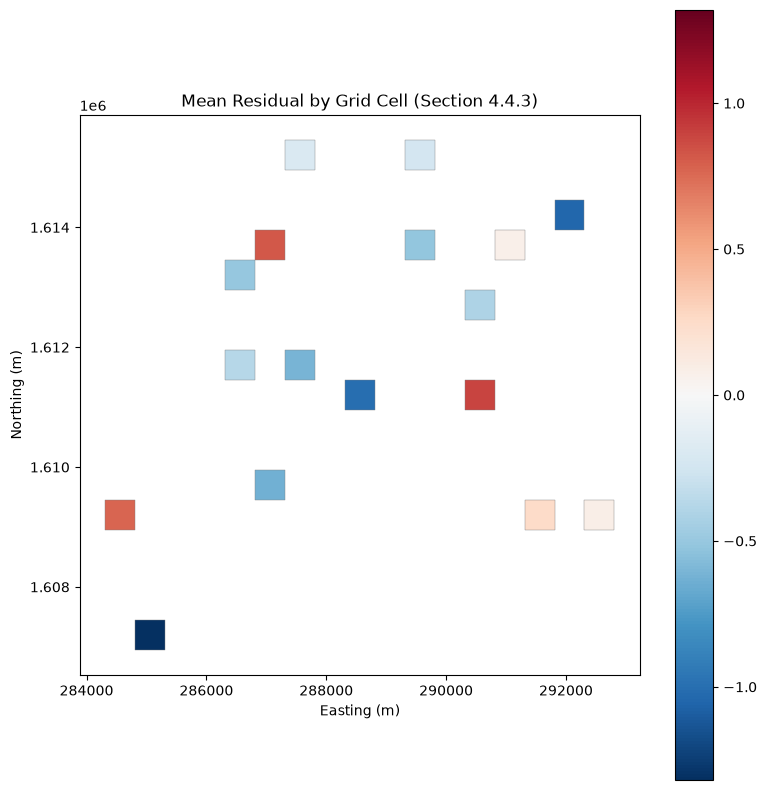

Global Moran's I = -0.0778 | p_sim = 0.4780
No statistically significant global spatial autocorrelation detected.


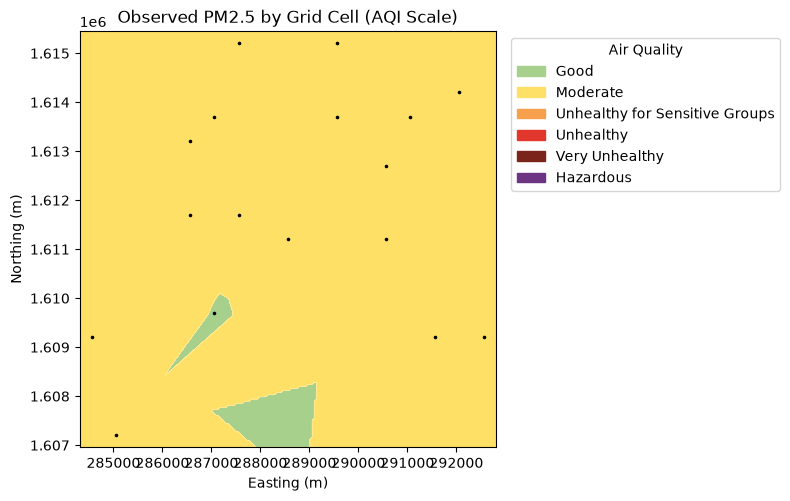

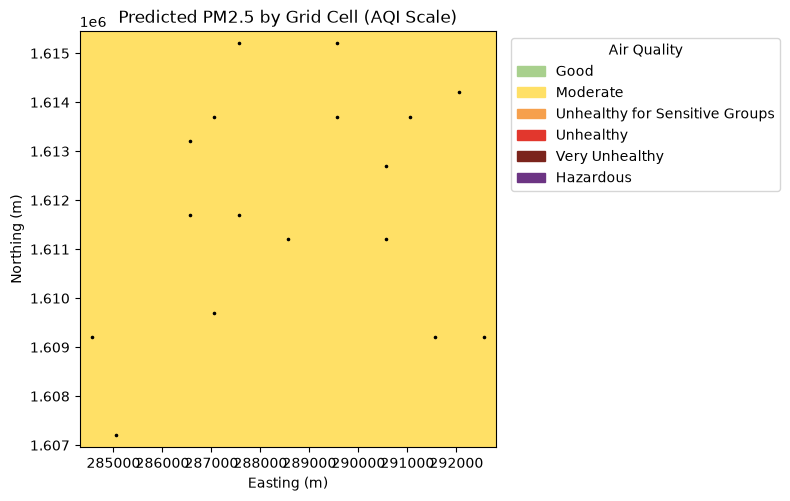

In [60]:
# Heavier configuration than the Section 4.3 smoke test: more epochs so the model actually fits
# something, and more rows per sensor, so the residuals reflect real model behavior rather than
# an undertrained model's noise. Still capped (not the full modeling_df) to keep runtime sane
# (see EVAL_SMOKE_TEST_ROWS_PER_SENSOR / EVAL_N_SPLITS in the Testing Parameters cell above).
eval_df = modeling_df.groupby("location_id").head(EVAL_SMOKE_TEST_ROWS_PER_SENSOR).reset_index(drop=True)
print(f"Evaluation frame: {eval_df.shape} across {eval_df['location_id'].nunique()} sensors")

candidates = load_hyperparameter_candidates(HYPERPARAMETER_CANDIDATES_PATH)
log = load_hyperparameter_log(HYPERPARAMETER_LOG_PATH)
candidates = filter_out_worst_candidates(candidates, log)
print(f"Trying {len(candidates)} hyperparameter candidate(s) from {HYPERPARAMETER_CANDIDATES_PATH}")

best_oof_df, best_metrics, best_hyperparams = None, None, None

for i, hyperparams in enumerate(candidates):
    print(f"\n--- Candidate {i + 1}/{len(candidates)}: {hyperparams} ---")
    oof_df = spatial_kfold_cv_evaluate(
        samples_df=eval_df,
        master_raster_path=master_tif_path,
        lag_cols=LAG_COLS,
        in_channels=in_channels,
        hyperparams=hyperparams,
        n_splits=EVAL_N_SPLITS,
    )
    metrics = summarize_oof_metrics(oof_df)
    log = append_hyperparameter_log(HYPERPARAMETER_LOG_PATH, hyperparams, metrics)

    if best_metrics is None or metrics["r2"] > best_metrics["r2"]:
        best_oof_df, best_metrics, best_hyperparams = oof_df, metrics, hyperparams

print(f"\nBest candidate this run: {best_hyperparams} | R2={best_metrics['r2']:.3f} "
      f"| RMSE={best_metrics['rmse']:.3f} | MAE={best_metrics['mae']:.3f}")

# Section 4.4.3: map each sensor to its grid cell, then test residuals for spatial autocorrelation
grid_gdf_from_csv = load_grid_from_csv("full_morphology_grid.csv")
sensor_grid_map = spatial_join_sensors_to_grid(valid_sensors_gdf, grid_gdf_from_csv)[["location_id", "grid_id"]]

global_result, lisa_result = detect_spatial_bias(
    best_oof_df, grid_gdf_from_csv, sensor_grid_map,
    k=MORANS_K_NEIGHBORS, permutations=MORANS_PERMUTATIONS, significance=MORANS_SIGNIFICANCE,
)

# PM2.5 severity heatmaps for the best candidate this run (observed vs. predicted), AQI-colored
actual_grid_df = aggregate_column_by_grid(best_oof_df, sensor_grid_map, "y_true")
actual_cells = grid_gdf_from_csv.merge(actual_grid_df, on="grid_id", how="inner")
plot_pm25_aqi_heatmap(actual_cells, value_col="y_true", title="Observed PM2.5 by Grid Cell (AQI Scale)")

predicted_grid_df = aggregate_column_by_grid(best_oof_df, sensor_grid_map, "y_pred")
predicted_cells = grid_gdf_from_csv.merge(predicted_grid_df, on="grid_id", how="inner")
_ = plot_pm25_aqi_heatmap(predicted_cells, value_col="y_pred", title="Predicted PM2.5 by Grid Cell (AQI Scale)")